Imports & Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sys.path.append("..")

# Notebook display settings
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

print("Setup complete!")

Setup complete!


Load Raw Data

In [2]:
df_raw = pd.read_csv("../data/raw/AAPL_data.csv", index_col="Date", parse_dates=True)

print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"Total trading days: {len(df_raw)}")
print(f"\nFirst 5 rows:")
df_raw.head()

Shape: (4139, 5)
Date range: 2010-01-04 → 2026-06-17
Total trading days: 4139

First 5 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,6.3891,6.4212,6.3577,6.4065,493729600
2010-01-05,6.4241,6.4538,6.3837,6.4176,601904800
2010-01-06,6.4176,6.4430,6.3089,6.3155,552160000
2010-01-07,6.3388,6.3463,6.2580,6.3038,477131200
2010-01-08,6.2954,6.3463,6.2583,6.3457,447610800


Basic Statistics

In [3]:
print("Basic Statistics — Raw OHLCV Data\n")
df_raw.describe()

Basic Statistics — Raw OHLCV Data



,Open,High,Low,Close,Volume
count,4139.0000,4139.0000,4139.0000,4139.0000,4139.0000
mean,82.7085,83.5980,81.8771,82.7723,214240459.5071
std,80.4616,81.3329,79.6708,80.5334,214342232.0368
min,5.7587,5.8673,5.6952,5.7491,17910600.0000
25%,18.5647,18.7032,18.3935,18.5614,74817000.0000
50%,40.3820,40.7440,40.1029,40.3350,127594400.0000
75%,146.6488,148.3782,145.2111,147.1131,282740400.0000
max,314.1800,317.4000,309.6500,315.2000,1880998000.0000


Missing Values Check

In [4]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()}")
print("No missing values — data is clean ✅" if df_raw.isnull().sum().sum() == 0 else "⚠️ Missing values found!")

Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Total missing: 0
No missing values — data is clean ✅


 AAPL Price History

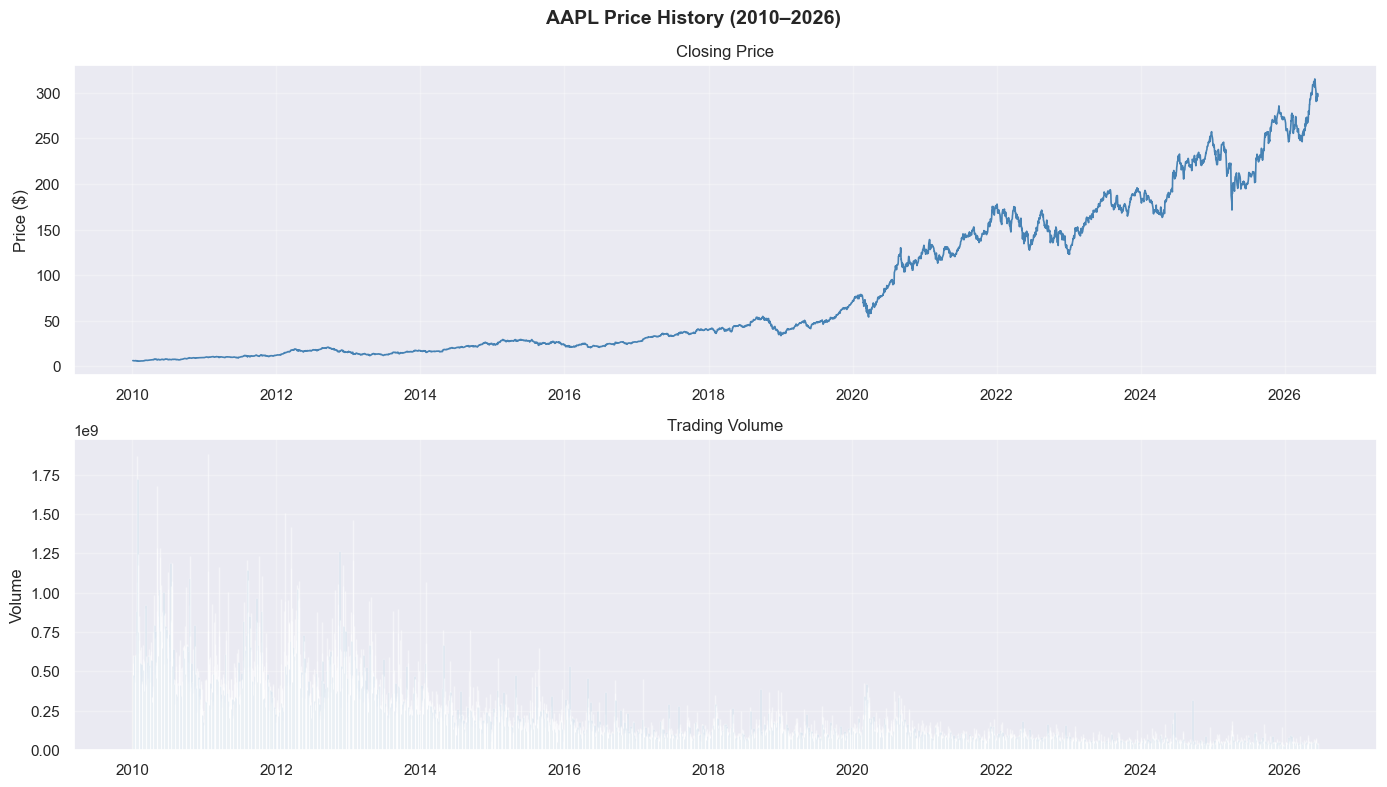

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("AAPL Price History (2010–2026)", fontsize=14, fontweight="bold")

# Closing price
axes[0].plot(df_raw.index, df_raw["Close"], color="steelblue", linewidth=1.2)
axes[0].set_title("Closing Price")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df_raw.index, df_raw["Volume"], color="steelblue", alpha=0.5, width=1)
axes[1].set_title("Trading Volume")
axes[1].set_ylabel("Volume")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/aapl_price_history.png", dpi=150, bbox_inches="tight")
plt.show()

Load Processed Data with Indicators

In [6]:
df_proc = pd.read_csv("../data/processed/AAPL_processed.csv", index_col="Date", parse_dates=True)

print(f"Processed shape: {df_proc.shape}")
print(f"Features: {df_proc.columns.tolist()}")
df_proc.head()

Processed shape: (4090, 16)
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI', 'MACD', 'MACD_signal', 'BB_high', 'BB_low', 'BB_width', 'ATR', 'OBV']


,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,BB_high,BB_low,BB_width,ATR,OBV
Date,,,,,,,,,,,,,,,,
2010-03-16,0.0004,0.0000,0.0023,0.0002,0.2303,0.0000,0.0000,0.0000,0.7205,0.5107,0.4639,0.0000,0.0000,0.0150,0.0018,0.2442
2010-03-17,0.0004,0.0001,0.0024,0.0002,0.2324,0.0001,0.0000,0.0001,0.7096,0.5107,0.4645,0.0001,0.0001,0.0152,0.0016,0.2242
2010-03-18,0.0004,0.0000,0.0023,0.0002,0.1740,0.0002,0.0000,0.0002,0.7176,0.5106,0.4649,0.0002,0.0002,0.0152,0.0013,0.2394
2010-03-19,0.0004,0.0000,0.0022,0.0000,0.2907,0.0003,0.0001,0.0002,0.6356,0.5102,0.4651,0.0003,0.0004,0.0148,0.0013,0.2145
2010-03-22,0.0000,0.0001,0.0021,0.0002,0.2354,0.0004,0.0001,0.0003,0.6785,0.5100,0.4653,0.0003,0.0006,0.0140,0.0016,0.2348


Technical Indicators Plot

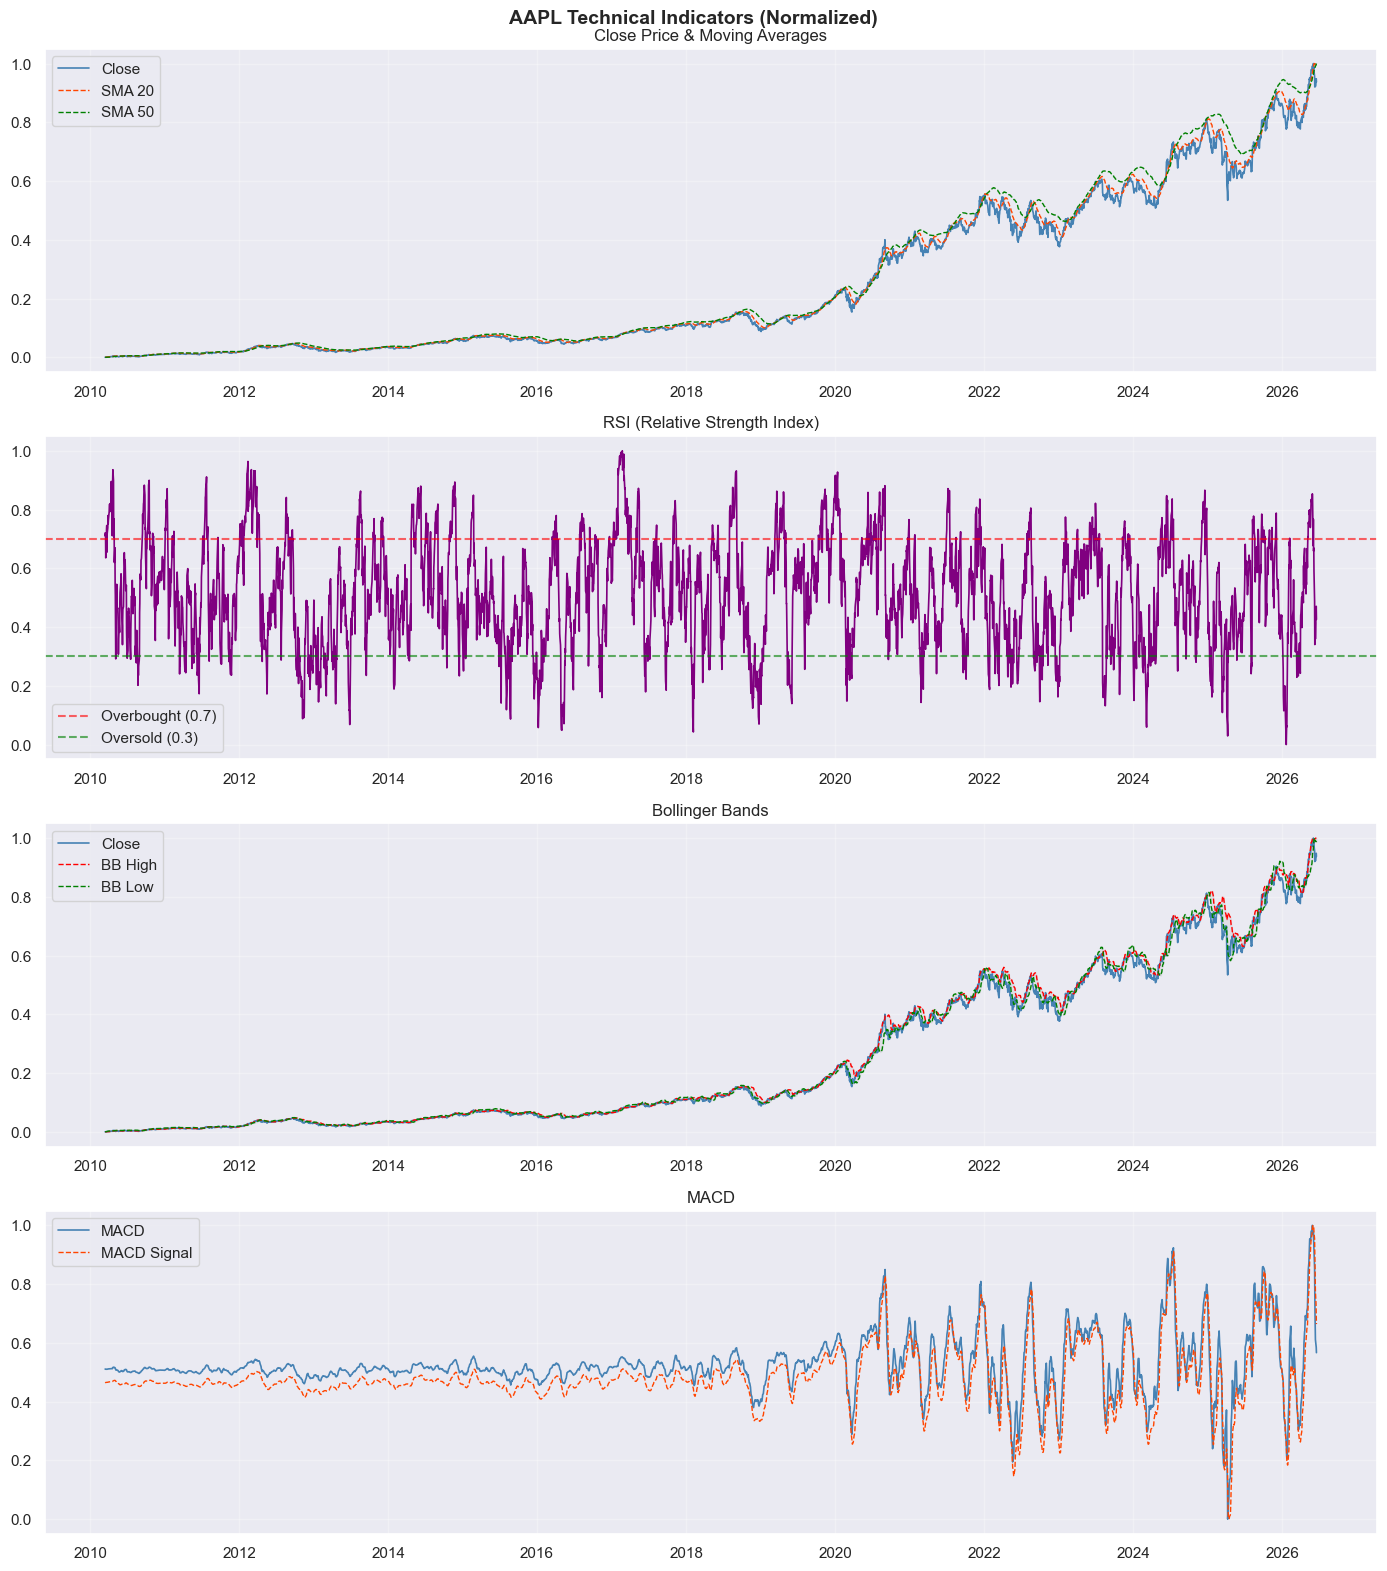

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("AAPL Technical Indicators (Normalized)", fontsize=14, fontweight="bold")

# Close price + Moving averages
axes[0].plot(df_proc.index, df_proc["Close"],  label="Close",  linewidth=1.2, color="steelblue")
axes[0].plot(df_proc.index, df_proc["SMA_20"], label="SMA 20", linewidth=1,   color="orangered",  linestyle="--")
axes[0].plot(df_proc.index, df_proc["SMA_50"], label="SMA 50", linewidth=1,   color="green",      linestyle="--")
axes[0].set_title("Close Price & Moving Averages")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df_proc.index, df_proc["RSI"], color="purple", linewidth=1.2)
axes[1].axhline(y=0.7, color="red",   linestyle="--", alpha=0.6, label="Overbought (0.7)")
axes[1].axhline(y=0.3, color="green", linestyle="--", alpha=0.6, label="Oversold (0.3)")
axes[1].set_title("RSI (Relative Strength Index)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Bollinger Bands
axes[2].plot(df_proc.index, df_proc["Close"],   label="Close",   color="steelblue", linewidth=1.2)
axes[2].plot(df_proc.index, df_proc["BB_high"], label="BB High", color="red",       linewidth=1, linestyle="--")
axes[2].plot(df_proc.index, df_proc["BB_low"],  label="BB Low",  color="green",     linewidth=1, linestyle="--")
axes[2].fill_between(df_proc.index, df_proc["BB_low"], df_proc["BB_high"], alpha=0.1, color="gray")
axes[2].set_title("Bollinger Bands")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# MACD
axes[3].plot(df_proc.index, df_proc["MACD"],        label="MACD",        color="steelblue", linewidth=1.2)
axes[3].plot(df_proc.index, df_proc["MACD_signal"], label="MACD Signal", color="orangered", linewidth=1, linestyle="--")
axes[3].set_title("MACD")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/technical_indicators.png", dpi=150, bbox_inches="tight")
plt.show()


 Correlation Heatmap

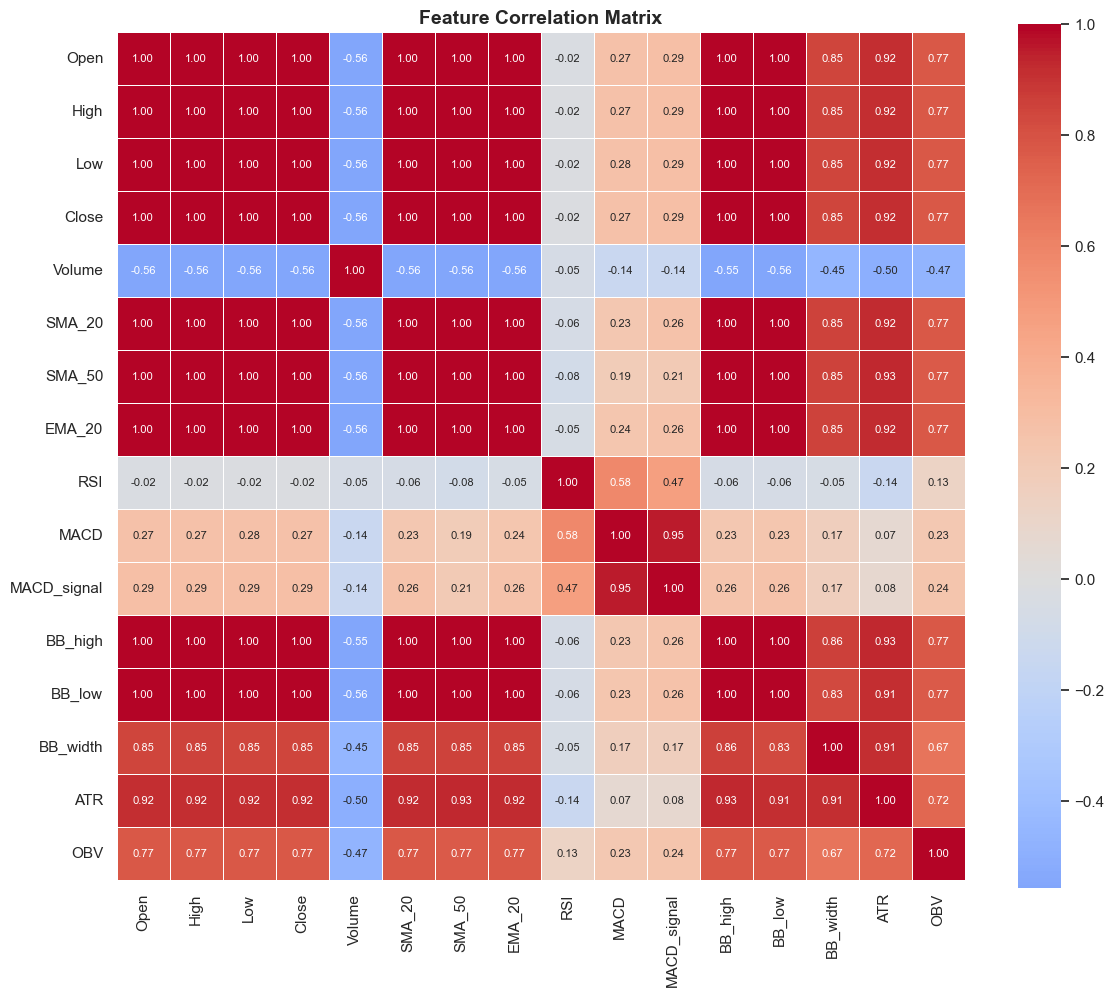

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

# Compute correlation matrix
corr = df_proc.corr()

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Price Return Distribution

C:\Users\Mahnoor\AppData\Local\Temp\ipykernel_264\1917984147.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(yearly, labels=sorted(returns_df["Year"].unique()), patch_artist=True)


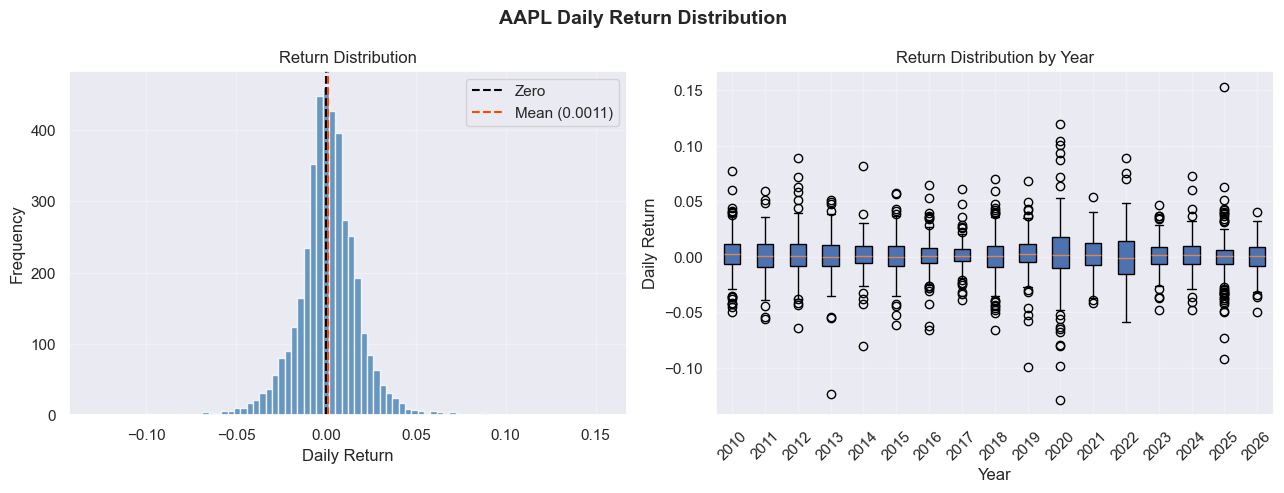


Return Statistics:
  Mean:     0.0011
  Std Dev:  0.0177
  Skewness: 0.0624
  Kurtosis: 6.1158


In [9]:
# Daily returns = percentage change in closing price
returns = df_raw["Close"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("AAPL Daily Return Distribution", fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(returns, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0,             color="black", linestyle="--", linewidth=1.5, label="Zero")
axes[0].axvline(x=returns.mean(), color="orangered", linestyle="--", linewidth=1.5, label=f"Mean ({returns.mean():.4f})")
axes[0].set_title("Return Distribution")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by year
returns_df = returns.to_frame()
returns_df["Year"] = returns_df.index.year
yearly = [returns_df[returns_df["Year"] == y]["Close"].values for y in sorted(returns_df["Year"].unique())]
axes[1].boxplot(yearly, labels=sorted(returns_df["Year"].unique()), patch_artist=True)
axes[1].set_title("Return Distribution by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Daily Return")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nReturn Statistics:")
print(f"  Mean:     {returns.mean():.4f}")
print(f"  Std Dev:  {returns.std():.4f}")
print(f"  Skewness: {returns.skew():.4f}")
print(f"  Kurtosis: {returns.kurtosis():.4f}")

Train/Val/Test Split Visualization

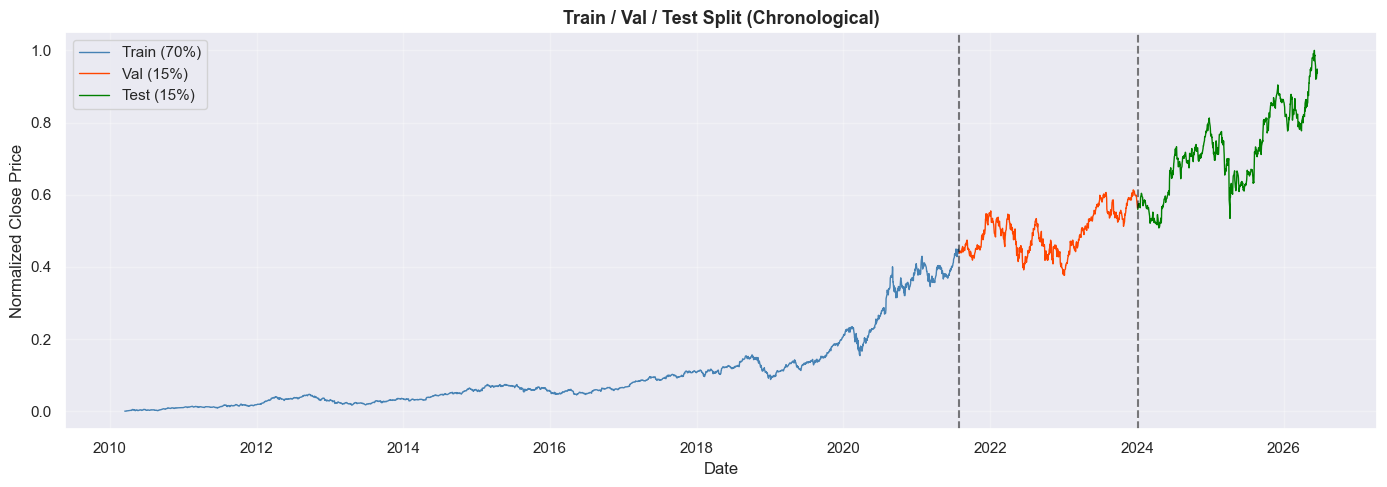

In [10]:
n = len(df_proc)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

fig, ax = plt.subplots(figsize=(14, 5))

# Plot each split in different color
ax.plot(df_proc.index[:train_end],        df_proc["Close"][:train_end],        color="steelblue",  linewidth=1, label="Train (70%)")
ax.plot(df_proc.index[train_end:val_end], df_proc["Close"][train_end:val_end], color="orangered",  linewidth=1, label="Val (15%)")
ax.plot(df_proc.index[val_end:],          df_proc["Close"][val_end:],          color="green",      linewidth=1, label="Test (15%)")

# Vertical split lines
ax.axvline(x=df_proc.index[train_end], color="black", linestyle="--", alpha=0.5)
ax.axvline(x=df_proc.index[val_end],   color="black", linestyle="--", alpha=0.5)

ax.set_title("Train / Val / Test Split (Chronological)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Close Price")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/data_split.png", dpi=150, bbox_inches="tight")
plt.show()